### Imports and Data

In [37]:
import os
import numpy as np
import matplotlib.pyplot as plt

import opinf

import utils
import config_lotka_volterra as config
import step1_generate_data as step1
# import step2_fitgps as step2
# import step3_estimate as step3
import step4_plot as step4

### Step 1: Generate Data

In [38]:
training_span = (0,7) #0,10
num_samples = 100 #30
noiselevel = .05 #20
num_regression_points = 300 #60
ndraws = 60
kernel = "rq*cos"
# Step 1: Generate data ---------------------------------------------------
sampler = step1.TrajectorySampler(
    training_span=training_span,
    num_samples=num_samples,
    noiselevel=noiselevel,
    num_regression_points=num_regression_points,
    synced=False,
    integersonly=False,
    config=config
)

(
    truthmodel,
    time_domain_prediction,
    true_states,
    time_domains_sampled,
    snapshots_sampled,
) = sampler.sample()
true_parameters = np.copy(truthmodel.parameters)
# truthmodel, time_domain_prediction.shape, true_states.shape, time_domains_sampled.shape, snapshots_sampled

### Step 2: Fit GPs

In [45]:
"""
Refactored gpkernels.py

Convenience classes for Gaussian process kernels.
This version provides a few base manual kernels (RBF, RQ, Cosine/Periodic) and
allows you to define a composite kernel on the fly by passing a string, e.g. "rbf*rq*cos".
"""

import math
import abc
import numpy as np
import torch
import gpytorch
from gpytorch.models import ExactGP
from gpytorch.likelihoods import GaussianLikelihood
from gpytorch.means import ZeroMean, ConstantMean
from gpytorch.kernels import Kernel

###############################################################################
# Base Class for Manual Kernels
###############################################################################

class ManualKernelBase(Kernel):
    """
    Base class for manual kernels.
    Provides a common compute_covariance method and helper for input preparation.
    """
    def compute_covariance(self, x1, x2):
        covar = self.forward(x1, x2)
        if hasattr(covar, "evaluate"):
            return covar.evaluate()
        return covar

    @staticmethod
    def _prepare_input(x):
        # If x is a 2D tensor with a single feature column, squeeze it.
        if x.dim() == 2 and x.shape[1] == 1:
            return x.squeeze(-1)
        return x

###############################################################################
# Base Manual Kernels
###############################################################################

class ManualRBFKernel(ManualKernelBase):
    """
    Custom kernel implementing a standard RBF (Gaussian) kernel.
    
    k(x, x') = amplitude * exp(-((x - x')^2) / (2 * lengthscale^2))
    """
    def __init__(self, **kwargs):
        super().__init__(has_lengthscale=False, **kwargs)
        self.register_parameter("raw_outputscale", torch.nn.Parameter(torch.tensor(1.0)))
        self.register_parameter("raw_lengthscale", torch.nn.Parameter(torch.tensor(1.0)))
        self.register_constraint("raw_outputscale", gpytorch.constraints.Positive())
        self.register_constraint("raw_lengthscale", gpytorch.constraints.Positive())
    
    def forward(self, x1, x2, diag=False, **params):
        outputscale = self.raw_outputscale_constraint.transform(self.raw_outputscale)
        lengthscale = self.raw_lengthscale_constraint.transform(self.raw_lengthscale)
        
        K = self.manual_rbf_kernel(x1, x2, amplitude=outputscale, lengthscale=lengthscale)
        return torch.diag(K) if diag else K

    @staticmethod
    def manual_rbf_kernel(x, x_prime, amplitude, lengthscale):
        x = ManualKernelBase._prepare_input(x)
        x_prime = ManualKernelBase._prepare_input(x_prime)
        diff = x.unsqueeze(1) - x_prime.unsqueeze(0)
        rbf_part = torch.exp(-0.5 * (diff**2) / (lengthscale**2))
        return amplitude * rbf_part


class ManualRQKernel(ManualKernelBase):
    """
    Custom kernel implementing a Rational Quadratic kernel.
    
    k(x, x') = amplitude * (1 + (x - x')^2 / (2 * alpha * lengthscale^2))^(-alpha)
    """
    def __init__(self, **kwargs):
        super().__init__(has_lengthscale=False, **kwargs)
        self.register_parameter("raw_outputscale", torch.nn.Parameter(torch.tensor(1.0)))
        self.register_parameter("raw_alpha", torch.nn.Parameter(torch.tensor(1.0)))
        self.register_parameter("raw_lengthscale", torch.nn.Parameter(torch.tensor(1.0)))
        self.register_constraint("raw_outputscale", gpytorch.constraints.Positive())
        self.register_constraint("raw_alpha", gpytorch.constraints.Positive())
        self.register_constraint("raw_lengthscale", gpytorch.constraints.Positive())
    
    def forward(self, x1, x2, diag=False, **params):
        outputscale = self.raw_outputscale_constraint.transform(self.raw_outputscale)
        alpha = self.raw_alpha_constraint.transform(self.raw_alpha)
        lengthscale = self.raw_lengthscale_constraint.transform(self.raw_lengthscale)
        
        K = self.manual_rq_kernel(x1, x2, amplitude=outputscale, alpha=alpha, lengthscale=lengthscale)
        return torch.diag(K) if diag else K

    @staticmethod
    def manual_rq_kernel(x, x_prime, amplitude, alpha, lengthscale):
        x = ManualKernelBase._prepare_input(x)
        x_prime = ManualKernelBase._prepare_input(x_prime)
        diff = x.unsqueeze(1) - x_prime.unsqueeze(0)
        diff_sq = diff.pow(2)
        rq_part = (1.0 + diff_sq / (2.0 * alpha * lengthscale**2)).pow(-alpha)
        return amplitude * rq_part


class ManualCosineKernel(ManualKernelBase):
    """
    Custom kernel implementing a Cosine kernel (often used for periodic behavior).
    
    k(x, x') = amplitude * cos(pi*(x - x')/period)
    """
    def __init__(self, **kwargs):
        super().__init__(has_lengthscale=False, **kwargs)
        self.register_parameter("raw_outputscale", torch.nn.Parameter(torch.tensor(1.0)))
        self.register_parameter("raw_period", torch.nn.Parameter(torch.tensor(1.0)))
        self.register_constraint("raw_outputscale", gpytorch.constraints.Positive())
        self.register_constraint("raw_period", gpytorch.constraints.Positive())
    
    def forward(self, x1, x2, diag=False, **params):
        outputscale = self.raw_outputscale_constraint.transform(self.raw_outputscale)
        period = self.raw_period_constraint.transform(self.raw_period)
        
        K = self.manual_cosine_kernel(x1, x2, amplitude=outputscale, period=period)
        return torch.diag(K) if diag else K

    @staticmethod
    def manual_cosine_kernel(x, x_prime, amplitude, period):
        x = ManualKernelBase._prepare_input(x)
        x_prime = ManualKernelBase._prepare_input(x_prime)
        diff = x.unsqueeze(1) - x_prime.unsqueeze(0)
        cos_part = torch.cos(math.pi * diff / period)
        return amplitude * cos_part

###############################################################################
# Composite Manual Kernel
###############################################################################

class ManualCompositeKernel(ManualKernelBase):
    """
    Composite manual kernel that multiplies several base manual kernels.
    Instead of returning a gpytorch ProductKernel, it implements its own 
    compute_covariance method by multiplying the covariances from each subkernel.
    """
    def __init__(self, kernels, **kwargs):
        super().__init__(has_lengthscale=False, **kwargs)
        self.kernels = torch.nn.ModuleList(kernels)

    def forward(self, x1, x2, diag=False, **params):
        covar = self.compute_covariance(x1, x2)
        return torch.diag(covar) if diag else covar

    def compute_covariance(self, x1, x2):
        # Start with an all-ones matrix (multiplicative identity)
        covar = torch.ones(x1.shape[0], x2.shape[0], device=x1.device, dtype=x1.dtype)
        for k in self.kernels:
            covar = covar * k.compute_covariance(x1, x2)
        return covar

###############################################################################
# Kernel Composition Helper
###############################################################################

def build_manual_kernel(kernel_str: str):
    """
    Build a composite manual kernel from a string.
    The string should contain base tokens separated by '*' (e.g. "rbf*rq*cos").
    
    Supported tokens:
      - "rbf": ManualRBFKernel
      - "rq": ManualRQKernel
      - "cos" or "periodic": ManualCosineKernel
    """
    token_to_class = {
        "rbf": ManualRBFKernel,
        "rq": ManualRQKernel,
        "cos": ManualCosineKernel,
        "periodic": ManualCosineKernel
    }
    tokens = kernel_str.lower().split("*")
    kernels = []
    for token in tokens:
        if token not in token_to_class:
            raise ValueError(f"Unknown kernel type: {token}")
        kernels.append(token_to_class[token]())
    if len(kernels) == 1:
        return kernels[0]
    else:
        return ManualCompositeKernel(kernels)

###############################################################################
# Generic Exact GP Model
###############################################################################

class GenericExactGP(ExactGP):
    """
    A generic ExactGP model that accepts a custom kernel and mean module.
    """
    def __init__(self, train_x, train_y, likelihood, mean_module=None, kernel=None):
        super().__init__(train_x, train_y, likelihood)
        self.mean_module = mean_module if mean_module is not None else ConstantMean()
        self.covar_module = kernel if kernel is not None else ManualRBFKernel()
    
    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

###############################################################################
# Base GP Wrapper and TORCH_GP
###############################################################################

class TorchBaseGP(abc.ABC):
    """
    Base class for gpytorch Gaussian process regressor wrappers.
    """
    def __init__(self):
        self.model = None
        self.likelihood = None
        self.t_training = None  # training inputs (1D tensor)
        self.y = None           # training targets (1D tensor)
        self.state_estimate = None
        self.ddt_estimate = None
        self.ddt_covariance = None
        self.sqrtW = None

    @property
    def nsamples(self):
        return self.t_training.size(0) if self.t_training is not None else 0

    def fit(self, t_training, training_data):
        if training_data.ndim > 1:
            raise ValueError("GP training data must be one-dimensional")
        # Store training data as tensors.
        self.t_training = torch.tensor(t_training, dtype=torch.float32)
        self.y = torch.tensor(training_data, dtype=torch.float32)
        self.likelihood = GaussianLikelihood()
        # Note: the model expects inputs with an extra feature dimension.
        train_x = self.t_training.unsqueeze(-1)
        train_y = self.y
        # Create a GenericExactGP model with the provided (or default) kernel and mean.
        self.model = GenericExactGP(
            train_x, train_y, self.likelihood,
            mean_module=self.mean_module if hasattr(self, 'mean_module') else None,
            kernel=self.kernel if hasattr(self, 'kernel') else None)
        self.model.train()
        self.likelihood.train()
        optimizer = torch.optim.Adam(self.model.parameters(), lr=0.1)
        mll = gpytorch.mlls.ExactMarginalLogLikelihood(self.likelihood, self.model)
        for i in range(self.training_iter):
            optimizer.zero_grad()
            output = self.model(train_x)
            loss = -mll(output, train_y)
            loss.backward()
            optimizer.step()
        return self

    def predict(self, t):
        t_tensor = torch.tensor(t, dtype=torch.float32).unsqueeze(-1) if not torch.is_tensor(t) else t
        self.model.eval()
        self.likelihood.eval()
        with torch.no_grad(), gpytorch.settings.fast_pred_var():
            pred = self.likelihood(self.model(t_tensor))
            # Attach .std for compatibility.
            pred.std = pred.stddev
        return pred

    def prediction_bounds(self, t, kind="95%"):
        pred = self.predict(t)
        mean, std = pred.mean, pred.std
        if kind == "std":
            width = std
        elif kind == "95%":
            width = 1.96 * std
        elif kind == "2std":
            width = 2 * std
        elif kind == "3std":
            width = 3 * std
        else:
            raise ValueError(kind)
        return mean - width, mean, mean + width

    @abc.abstractmethod
    def compute_lstsq_matrices(self, t_est, **kwargs):
        r"""Compute data needed for the GP-BayesOpInf least squares."""
        raise NotImplementedError

    def _compute_estimates_and_weights(self,
                                       K_yy: torch.Tensor,
                                       K_zy: torch.Tensor,
                                       K_zz: torch.Tensor,
                                       kappa_zy: torch.Tensor,
                                       eta: float = 1e-8):
        L = torch.linalg.cholesky(K_yy)
        y_unsq = self.y.unsqueeze(-1)
        K_yy_inv_y = torch.cholesky_solve(y_unsq, L)
        self.state_estimate = (kappa_zy @ K_yy_inv_y).squeeze(-1).detach().numpy().astype(np.float64)
        self.ddt_estimate = (K_zy @ K_yy_inv_y).squeeze(-1).detach().numpy().astype(np.float64)
        K_zy_inv = torch.cholesky_solve(K_zy.T, L)
        ddt_covariance = K_zz - K_zy @ K_zy_inv
        self.ddt_covariance = ddt_covariance
        C = ddt_covariance
        C_reg = C + eta * torch.eye(C.size(0), device=C.device, dtype=C.dtype)
        evals, evecs = torch.linalg.eigh(C_reg)
        if torch.any(evals <= 0):
            raise ValueError(f"inverse covariance not positive definite, increase eta...previous value {eta}")
        self.sqrtW = (evecs @ torch.diag(1.0 / torch.sqrt(evals)) @ evecs.T).detach().numpy().astype(np.float64)


class TORCH_GP(TorchBaseGP):
    """
    Gaussian process regressor with a customizable kernel.
    You can specify the kernel either by passing a kernel instance or a string.
    For example: TORCH_GP(training_iter=100, kernel="rbf*rq*cos")
    """
    def __init__(self, training_iter=100, kernel=None, mean_module=None):
        super().__init__()
        self.training_iter = training_iter
        # Allow passing a custom kernel as an instance or via a string.
        if isinstance(kernel, str):
            self.kernel = build_manual_kernel(kernel)
        else:
            self.kernel = kernel if kernel is not None else ManualRBFKernel()
        # Optionally allow a custom mean module; default to ConstantMean.
        self.mean_module = mean_module if mean_module is not None else ConstantMean()

    def __str__(self):
        return f"TORCH_GP with kernel: {self.kernel.__class__.__name__}"

    def compute_lstsq_matrices(self, t_est, eta):
        self.t_estimation = t_est
        t_est_tensor = torch.tensor(t_est, dtype=torch.float32) if not torch.is_tensor(t_est) else t_est
        t_est_tensor.requires_grad_()
        t_train_tensor = self.t_training if torch.is_tensor(self.t_training) else torch.tensor(self.t_training, dtype=torch.float32)
        kernel = self.model.covar_module
        
        rbf_yy = kernel.compute_covariance(t_train_tensor, t_train_tensor)
        rbf_zy = kernel.compute_covariance(t_est_tensor, t_train_tensor)
        rbf_zz = kernel.compute_covariance(t_est_tensor, t_est_tensor)

        def kernel_func(x1):
            return kernel.compute_covariance(x1, t_train_tensor)
        jacobian_K = torch.autograd.functional.jacobian(kernel_func, t_est_tensor)
        dk_dx1_autograd = torch.zeros_like(rbf_zy)
        for i in range(t_est_tensor.shape[0]):
            dk_dx1_autograd[i, :] = jacobian_K[i, :, i]

        mixed_derivs = torch.zeros_like(rbf_zz)
        for i in range(t_est_tensor.shape[0]):
            for j in range(t_est_tensor.shape[0]):
                xi = t_est_tensor[i:i+1].clone().detach().requires_grad_(True)
                yj = t_est_tensor[j:j+1].clone().detach().requires_grad_(True)
                k_val = kernel.compute_covariance(xi, yj)
                grad_x = torch.autograd.grad(k_val, xi, create_graph=True)[0]
                mixed = torch.autograd.grad(grad_x, yj)[0]
                mixed_derivs[i, j] = mixed

        noise_val = self.model.likelihood.noise.item()
        K_yy = rbf_yy + torch.diag(torch.full((rbf_yy.size(0),), noise_val,
                                                dtype=rbf_yy.dtype,
                                                device=rbf_yy.device))
        K_zy = dk_dx1_autograd
        K_zz = mixed_derivs
        self._compute_estimates_and_weights(K_yy, K_zy, K_zz, rbf_zy, eta)
        return self


In [46]:
# import gpkernels
from typing import Iterable

def torch_fit_single_gaussian_process(
    stateindex: int,
    time_domain_training: np.ndarray,
    time_domain_sampled: np.ndarray,
    state_variable_sampled: np.ndarray,
    config,
    gp_regularizer: float = 1e-8,
) -> TORCH_GP:
    """Fit a single Gaussian process (GP) to snapshot data for one variable.

    Parameters
    ----------
    stateindex : int
        Index of the state variable.
    time_domain_training : (m',) ndarray
        Time domain at which to estimate states and time derivatives
        for the parameter estimation.
    time_domain_sampled : (m,) ndarray
        Time domain corresponding to the available training snapshots.
    state_variable_sampled : (m,) ndarray
        Observations of a single state variable over the time domain
        ``time_domain_sampled``.
    gp_regularizer : float >= 0
        Regularization hyperparameter for the GP inference in inverting for
        the least-squares weight matrix.

    Returns
    -------
    gpkernels.GP_RBFW
        One-dimensional Gaussian process with parameters fit to training data.
    """
    with opinf.utils.TimedBlock(
        f"\nfitting GP model for state '{config.DIMFMT(stateindex)}'\n"
    ):
        gp = TORCH_GP(
            kernel=kernel
            # config.CONSTANT_VALUE_BOUNDS,
            # config.LENGTH_SCALE_BOUNDS,
            # config.NOISE_LEVEL_BOUNDS,
            # config.N_RESTARTS_OPTIMIZER,
        )
        gp.fit(time_domain_sampled, state_variable_sampled)
        print(gp)

    with opinf.utils.TimedBlock("computing weight matrix", timelimit=600):
        gp.compute_lstsq_matrices(time_domain_training, eta=gp_regularizer)

    return gp


def torch_fit_gaussian_processes(
    time_domain_training: np.ndarray,
    time_domains_sampled: list[np.ndarray],
    snapshots_sampled: np.ndarray,
    config,
    gp_regularizer: float = 1e-8,
) -> Iterable[TORCH_GP]:
    """Fit Gaussian Process (GP) regression models to the snapshot data,
    one state variable at a time.

    Parameters
    ----------
    time_domain_training : (m',) ndarray
        Time domain at which to estimate states and time derivatives
        for the parameter estimation.
    time_domains_sampled : list of num_variables (m,) ndarrays
        Time domains corresponding to the available training snapshots,
        one for each variable.
    snapshots_sampled : (num_variables, m) ndarray
        Observed training snapshots.
    """
    return [
        torch_fit_single_gaussian_process(
            stateindex=stateindex,
            time_domain_training=time_domain_training,
            time_domain_sampled=time_domains_sampled[stateindex],
            state_variable_sampled=snapshots_sampled[stateindex],
            config=config,
            gp_regularizer=gp_regularizer,
        )
        for stateindex in range(config.NUMVARS)
    ]


fitting GP model for state 'Prey'...
TORCH_GP with kernel: ManualCompositeKernel
done in 0.14 s.
computing weight matrix...done in 37.13 s.

fitting GP model for state 'Predator'...
TORCH_GP with kernel: ManualCompositeKernel
done in 0.11 s.
computing weight matrix...done in 36.97 s.


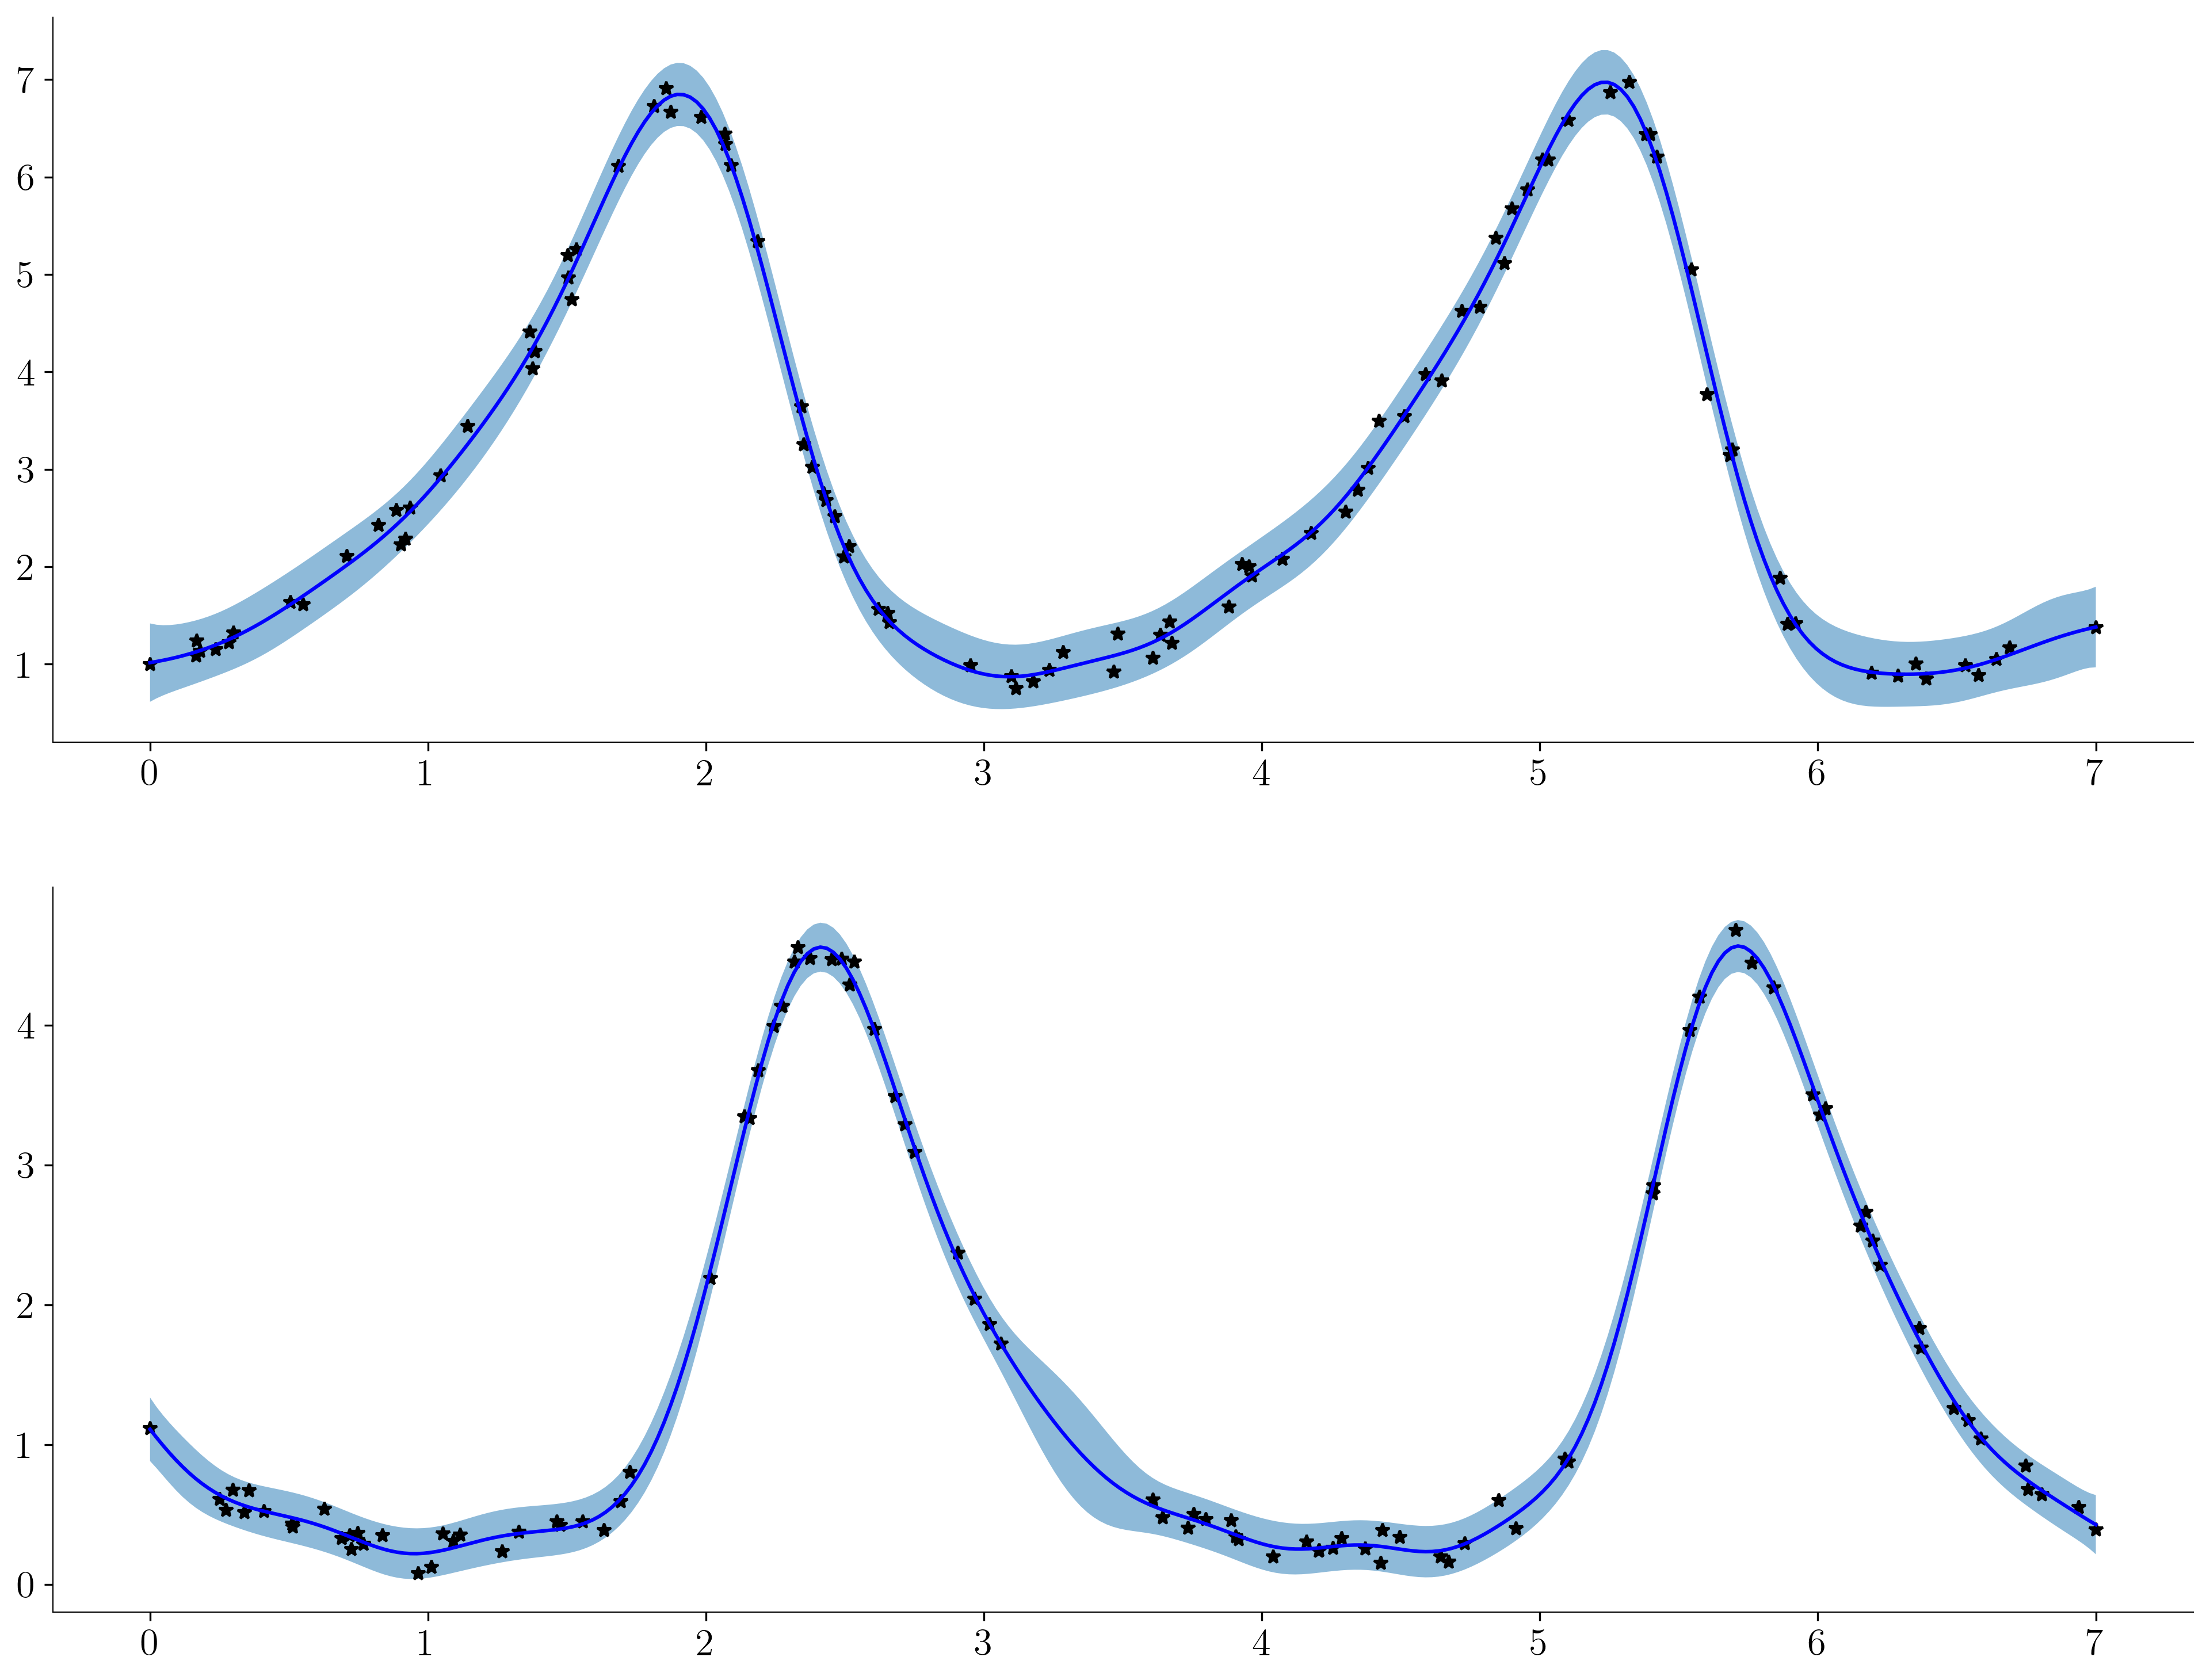

In [47]:
# Step 2: Fit Gaussian processes to data ----------------------------------
time_domain_training = np.linspace(
    training_span[0],
    training_span[-1],
    num_regression_points,
)

gps = torch_fit_gaussian_processes(
    time_domain_training=time_domain_training,
    time_domains_sampled=time_domains_sampled,
    snapshots_sampled=snapshots_sampled,
    gp_regularizer=1e-0,
    config=config
)

gp_predictions = [gp.predict(time_domain_training) for gp in gps]
gp_means = np.array([ms.mean for ms in gp_predictions])
gp_stds=np.array([ms.stddev for ms in gp_predictions])

fig, ax = plt.subplots(2,1, figsize=(16,12))
for i in range(2):
    lower, upper = gp_predictions[i].confidence_region()
    ax[i].plot(time_domains_sampled[i], snapshots_sampled[i], 'k*')
    ax[i].plot(time_domain_training, gp_predictions[i].mean, 'b')
    ax[i].fill_between(time_domain_training, lower, upper, alpha=.5)

### Step 3: Construct Posterior

In [48]:
import step3_estimate
bayesian_model = step3_estimate.estimate_posterior(
    gps=gps,
    time_domain_prediction=time_domain_prediction,
    config=config
)
# utils.summarize_posterior(true_parameters, bayesian_model)

constructing posterior hyperparameters...

GRIDSEARCH
(1/22) Testing regularizer 1.0000e-16...8.32% error
(2/22) Testing regularizer 1.0000e-15...8.31% error
(3/22) Testing regularizer 1.0000e-14...8.83% error
(4/22) Testing regularizer 1.0000e-13...6.09% error
(5/22) Testing regularizer 1.0000e-12...11.44% error
(6/22) Testing regularizer 1.0000e-11...9.36% error
(7/22) Testing regularizer 1.0000e-10...9.51% error
(8/22) Testing regularizer 1.0000e-09...8.89% error
(9/22) Testing regularizer 1.0000e-08...9.64% error
(10/22) Testing regularizer 1.0000e-07...6.69% error
(11/22) Testing regularizer 1.0000e-06...10.43% error
(12/22) Testing regularizer 1.0000e-05...10.65% error
(13/22) Testing regularizer 1.0000e-04...11.62% error
(14/22) Testing regularizer 1.0000e-03...9.69% error
(15/22) Testing regularizer 1.0000e-02...8.90% error
(16/22) Testing regularizer 1.0000e-01...8.99% error
(17/22) Testing regularizer 1.0000e+00...9.87% error
(18/22) Testing regularizer 1.0000e+01...73.04% er

### Step 4: Plot Results

In [49]:
# Draw samples from the posterior.
ICs = true_states[:, 0]
with opinf.utils.TimedBlock("\nsampling posterior distribution"):
    draws = bayesian_model.solution_posterior(
        initial_conditions=ICs,
        timepoints=time_domain_prediction,
        ndraws=ndraws,
    )

# Step 4: plot results ----------------------------------------------------
gp_predictions = [gp.predict(time_domain_training) for gp in gps]
gp_means = np.array([ms.mean for ms in gp_predictions])
gp_stds=np.array([ms.stddev for ms in gp_predictions])

print(np.array(gp_means).shape)

plotter = step4.ODEPlotter(
    sampling_time_domain=time_domains_sampled,
    training_time_domain=time_domain_training,
    prediction_time_domain=time_domain_prediction,
    snapshots=snapshots_sampled,
    true_states=true_states,
    gp_means = gp_means,
    gp_stds = gp_stds,
    draws=draws,
    labels=truthmodel.LABELS,
    config=config
)


sampling posterior distribution...done in 0.34 s.
(2, 300)


In [50]:
# If desired, export experimental data to HDF5 files for later.
exportto = "data/lotka_volterra/ex1a"
openonsave = False
if exportto is not None:
    os.makedirs(os.path.dirname(exportto), exist_ok=True)
    dfile = f"{exportto}_data.h5"
    with opinf.utils.TimedBlock(f"exporting data to {dfile}"):
        plotter.save(dfile, overwrite=True)

# Plot and save results.
with opinf.utils.TimedBlock("\nplotting GP training fit\n"):
    # Gaussian process fit.
    plotter.plot_gp_training_fit(width=3)
    utils.save_figure("train.pdf", andopen=openonsave)

    # Bayesian model performance.
    for k, flag in enumerate((True, False)):
        plotter.plot_posterior(individual=flag)
        utils.save_figure(f"predict{k}.pdf", andopen=openonsave)

# Prediction at different initial conditions.
# if config.test_initial_conditions is None:
#     return
test_trajectory = truthmodel.solve(
    config.test_initial_conditions,
    time_domain_prediction,
    strict=True,
)
with opinf.utils.TimedBlock("sampling posterior distribution"):
    draws = bayesian_model.solution_posterior(
        initial_conditions=config.test_initial_conditions,
        timepoints=time_domain_prediction,
        ndraws=ndraws,
    )

fig = plotter.plot_posterior_newICs(draws, truth=test_trajectory)
utils.save_figure("newtrajectory.pdf", andopen=openonsave, fig=fig)

exporting data to data/lotka_volterra/ex1a_data.h5...done in 0.00 s.

plotting GP training fit...
Saving /Users/anthonypoole/Repositories/GP-BayesOpInf/ODEs/figures/mar18/12-49-37/train.pdf...done in 0.08 s.
Saving /Users/anthonypoole/Repositories/GP-BayesOpInf/ODEs/figures/mar18/12-49-37/predict0.pdf...done in 0.12 s.
Saving /Users/anthonypoole/Repositories/GP-BayesOpInf/ODEs/figures/mar18/12-49-37/predict1.pdf...done in 0.08 s.
done in 0.43 s.
sampling posterior distribution...

/Users/anthonypoole/miniconda3/envs/gpbayesopinf/lib/python3.12/site-packages/scipy/integrate/_ivp/ivp.py:621: UserWarning: The following arguments have no effect for a chosen solver: `strict`.
  solver = method(fun, t0, y0, tf, vectorized=vectorized, **options)


done in 0.30 s.
Saving /Users/anthonypoole/Repositories/GP-BayesOpInf/ODEs/figures/mar18/12-49-37/newtrajectory.pdf...done in 0.07 s.


In [ ]:
"""
gpkernels.py

Convenience classes for Gaussian process kernels.
This version refactors the manual covariance computation into a custom gpytorch kernel.
It allows training via gpytorch and, after training, you can obtain a manual (dense) covariance
using the current hyperparameters.
"""

import math
import abc
import numpy as np
import torch
import gpytorch
from gpytorch.models import ExactGP
from gpytorch.likelihoods import GaussianLikelihood
from gpytorch.means import ZeroMean, ConstantMean
from gpytorch.kernels import Kernel

###############################################################################
# Custom Kernel Classes
###############################################################################

class ManualCosineRQKernel(Kernel):
    """
    Custom kernel implementing a Cosine * Rational Quadratic kernel.
    
    k(x, x') = amplitude * cos(pi*(x-x')/period) * (1 + (x-x')^2/(2*alpha*lengthscale^2))^(-alpha)
    """
    def __init__(self, **kwargs):
        super().__init__(has_lengthscale=False, **kwargs)
        # Register raw parameters.
        self.register_parameter("raw_outputscale", torch.nn.Parameter(torch.tensor(1.0)))
        self.register_parameter("raw_period", torch.nn.Parameter(torch.tensor(1.0)))
        self.register_parameter("raw_alpha", torch.nn.Parameter(torch.tensor(1.0)))
        self.register_parameter("raw_lengthscale", torch.nn.Parameter(torch.tensor(1.0)))
        # Register constraints.
        self.register_constraint("raw_outputscale", gpytorch.constraints.Positive())
        self.register_constraint("raw_period", gpytorch.constraints.Positive())
        self.register_constraint("raw_alpha", gpytorch.constraints.Positive())
        self.register_constraint("raw_lengthscale", gpytorch.constraints.Positive())
    
    def forward(self, x1, x2, diag=False, **params):
        # Transform raw parameters.
        outputscale = self.raw_outputscale_constraint.transform(self.raw_outputscale)
        period = self.raw_period_constraint.transform(self.raw_period)
        alpha = self.raw_alpha_constraint.transform(self.raw_alpha)
        lengthscale = self.raw_lengthscale_constraint.transform(self.raw_lengthscale)
        
        K = self.manual_cosine_rq_kernel(x1, x2,
                                         amplitude=outputscale,
                                         period=period,
                                         alpha=alpha,
                                         lengthscale=lengthscale)
        if diag:
            return torch.diag(K)
        return K

    @staticmethod
    def manual_cosine_rq_kernel(x, x_prime, amplitude, period, alpha, lengthscale):
        # Ensure inputs are 1D when possible.
        if x.dim() == 2 and x.shape[1] == 1:
            x = x.squeeze(-1)
        if x_prime.dim() == 2 and x_prime.shape[1] == 1:
            x_prime = x_prime.squeeze(-1)
        diff = x.unsqueeze(1) - x_prime.unsqueeze(0)
        cos_part = torch.cos(math.pi * diff / period)
        diff_sq = diff.pow(2)
        rq_part = (1.0 + diff_sq / (2.0 * alpha * lengthscale**2)).pow(-alpha)
        return amplitude * cos_part * rq_part
    
    def compute_covariance(self, x1, x2):
        covar = self.forward(x1, x2)
        if hasattr(covar, "evaluate"):
            return covar.evaluate()
        return covar


class ManualCosineRBFKernel(Kernel):
    """
    Custom kernel implementing a Cosine * RBF kernel.
    
    k(x, x') = amplitude * cos(pi*(x-x')/period) * exp(-((x-x')^2)/(2*lengthscale^2))
    """
    def __init__(self, **kwargs):
        super().__init__(has_lengthscale=False, **kwargs)
        self.register_parameter("raw_outputscale", torch.nn.Parameter(torch.tensor(1.0)))
        self.register_parameter("raw_period", torch.nn.Parameter(torch.tensor(1.0)))
        self.register_parameter("raw_lengthscale", torch.nn.Parameter(torch.tensor(1.0)))
        self.register_constraint("raw_outputscale", gpytorch.constraints.Positive())
        self.register_constraint("raw_period", gpytorch.constraints.Positive())
        self.register_constraint("raw_lengthscale", gpytorch.constraints.Positive())
    
    def forward(self, x1, x2, diag=False, **params):
        outputscale = self.raw_outputscale_constraint.transform(self.raw_outputscale)
        period = self.raw_period_constraint.transform(self.raw_period)
        lengthscale = self.raw_lengthscale_constraint.transform(self.raw_lengthscale)
        
        K = self.manual_cosine_rbf_kernel(x1, x2,
                                          amplitude=outputscale,
                                          period=period,
                                          lengthscale=lengthscale)
        if diag:
            return torch.diag(K)
        return K

    @staticmethod
    def manual_cosine_rbf_kernel(x, x_prime, amplitude, period, lengthscale):
        if x.dim() == 2 and x.shape[1] == 1:
            x = x.squeeze(-1)
        if x_prime.dim() == 2 and x_prime.shape[1] == 1:
            x_prime = x_prime.squeeze(-1)
        diff = x.unsqueeze(1) - x_prime.unsqueeze(0)
        cos_part = torch.cos(math.pi * diff / period)
        rbf_part = torch.exp(-0.5 * (diff**2) / (lengthscale**2))
        return amplitude * cos_part * rbf_part

    def compute_covariance(self, x1, x2):
        covar = self.forward(x1, x2)
        if hasattr(covar, "evaluate"):
            return covar.evaluate()
        return covar


class ManualCosineKernel(Kernel):
    """
    Custom kernel implementing a Cosine kernel.
    
    k(x, x') = amplitude * cos(pi*(x-x')/period)
    """
    def __init__(self, **kwargs):
        super().__init__(has_lengthscale=False, **kwargs)
        self.register_parameter("raw_outputscale", torch.nn.Parameter(torch.tensor(1.0)))
        self.register_parameter("raw_period", torch.nn.Parameter(torch.tensor(1.0)))
        self.register_constraint("raw_outputscale", gpytorch.constraints.Positive())
        self.register_constraint("raw_period", gpytorch.constraints.Positive())
    
    def forward(self, x1, x2, diag=False, **params):
        outputscale = self.raw_outputscale_constraint.transform(self.raw_outputscale)
        period = self.raw_period_constraint.transform(self.raw_period)
        
        K = self.manual_cosine_kernel(x1, x2, amplitude=outputscale, period=period)
        if diag:
            return torch.diag(K)
        return K

    @staticmethod
    def manual_cosine_kernel(x, x_prime, amplitude, period):
        if x.dim() == 2 and x.shape[1] == 1:
            x = x.squeeze(-1)
        if x_prime.dim() == 2 and x_prime.shape[1] == 1:
            x_prime = x_prime.squeeze(-1)
        diff = x.unsqueeze(1) - x_prime.unsqueeze(0)
        cos_part = torch.cos(math.pi * diff / period)
        return amplitude * cos_part

    def compute_covariance(self, x1, x2):
        covar = self.forward(x1, x2)
        if hasattr(covar, "evaluate"):
            return covar.evaluate()
        return covar

class ManualRBFKernel(Kernel):
    """
    Custom kernel implementing a standard RBF (Gaussian) kernel.
    
    k(x, x') = amplitude * exp(-((x - x')^2) / (2 * lengthscale^2))
    """
    def __init__(self, **kwargs):
        super().__init__(has_lengthscale=False, **kwargs)
        self.register_parameter("raw_outputscale", torch.nn.Parameter(torch.tensor(1.0)))
        self.register_parameter("raw_lengthscale", torch.nn.Parameter(torch.tensor(1.0)))
        self.register_constraint("raw_outputscale", gpytorch.constraints.Positive())
        self.register_constraint("raw_lengthscale", gpytorch.constraints.Positive())
    
    def forward(self, x1, x2, diag=False, **params):
        outputscale = self.raw_outputscale_constraint.transform(self.raw_outputscale)
        lengthscale = self.raw_lengthscale_constraint.transform(self.raw_lengthscale)
        
        K = self.manual_rbf_kernel(x1, x2, amplitude=outputscale, lengthscale=lengthscale)
        if diag:
            return torch.diag(K)
        return K

    @staticmethod
    def manual_rbf_kernel(x, x_prime, amplitude, lengthscale):
        if x.dim() == 2 and x.shape[1] == 1:
            x = x.squeeze(-1)
        if x_prime.dim() == 2 and x_prime.shape[1] == 1:
            x_prime = x_prime.squeeze(-1)
        diff = x.unsqueeze(1) - x_prime.unsqueeze(0)
        rbf_part = torch.exp(-0.5 * (diff**2) / (lengthscale**2))
        return amplitude * rbf_part

    def compute_covariance(self, x1, x2):
        covar = self.forward(x1, x2)
        if hasattr(covar, "evaluate"):
            return covar.evaluate()
        return covar

################################################################################################################################################
# GPS #
################################################################################################################################################

class ExactGPRBF(ExactGP):
    """
    GP model that uses the custom RBF kernel.
    """
    def __init__(self, train_x, train_y, likelihood):
        super().__init__(train_x, train_y, likelihood)
        self.mean_module = ConstantMean()
        self.covar_module = ManualRBFKernel()
    
    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)


class ExactGPCosineRQ(ExactGP):
    """
    GP model that uses the custom Cosine-RQ kernel.
    """
    def __init__(self, train_x, train_y, likelihood):
        super().__init__(train_x, train_y, likelihood)
        self.mean_module = ZeroMean()
        self.covar_module = ManualCosineRQKernel()
    
    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)


class ExactGPCosineRBF(ExactGP):
    """
    GP model that uses the custom Cosine-RBF kernel.
    """
    def __init__(self, train_x, train_y, likelihood):
        super().__init__(train_x, train_y, likelihood)
        self.mean_module = ConstantMean()
        self.covar_module = ManualRBFKernel()
    
    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)


class ExactGPCosine(ExactGP):
    """
    GP model that uses the custom Cosine kernel.
    """
    def __init__(self, train_x, train_y, likelihood):
        super().__init__(train_x, train_y, likelihood)
        self.mean_module = ZeroMean()
        self.covar_module = ManualCosineKernel()
    
    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)


###############################################################################
# Base GP Wrapper and TORCH_GP
###############################################################################

class TorchBaseGP(abc.ABC):
    """
    Base class for gpytorch Gaussian process regressor wrappers.
    """
    def __init__(self):
        self.model = None
        self.likelihood = None
        self.t_training = None  # training inputs (1D tensor)
        self.y = None           # training targets (1D tensor)
        self.state_estimate = None
        self.ddt_estimate = None
        self.ddt_covariance = None
        self.sqrtW = None

    @property
    def nsamples(self):
        return self.t_training.size(0) if self.t_training is not None else 0

    def fit(self, t_training, training_data):
        if training_data.ndim > 1:
            raise ValueError("GP training data must be one-dimensional")
        # Store training data as tensors.
        self.t_training = torch.tensor(t_training, dtype=torch.float32)
        self.y = torch.tensor(training_data, dtype=torch.float32)
        self.likelihood = GaussianLikelihood()
        # Note: the model expects inputs with an extra feature dimension.
        train_x = self.t_training.unsqueeze(-1)
        train_y = self.y
        # Default to using the Cosine-RQ GP model.
        self.model = ExactGPRBF(train_x, train_y, self.likelihood)
        self.model.train()
        self.likelihood.train()
        optimizer = torch.optim.Adam(self.model.parameters(), lr=0.1)
        mll = gpytorch.mlls.ExactMarginalLogLikelihood(self.likelihood, self.model)
        for i in range(self.training_iter):
            optimizer.zero_grad()
            output = self.model(train_x)
            loss = -mll(output, train_y)
            loss.backward()
            optimizer.step()
        return self

    def predict(self, t):
        t_tensor = torch.tensor(t, dtype=torch.float32).unsqueeze(-1) if not torch.is_tensor(t) else t
        self.model.eval()
        self.likelihood.eval()
        with torch.no_grad(), gpytorch.settings.fast_pred_var():
            pred = self.likelihood(self.model(t_tensor))
            # Attach .std for compatibility.
            pred.std = pred.stddev
        return pred

    def prediction_bounds(self, t, kind="95%"):
        pred = self.predict(t)
        mean, std = pred.mean, pred.std
        if kind == "std":
            width = std
        elif kind == "95%":
            width = 1.96 * std
        elif kind == "2std":
            width = 2 * std
        elif kind == "3std":
            width = 3 * std
        else:
            raise ValueError(kind)
        return mean - width, mean, mean + width


    @abc.abstractmethod
    def compute_lstsq_matrices(self, t_est, **kwargs):
        r"""Compute data needed for the GP-BayesOpInf least squares."""
        raise NotImplementedError

    def _compute_estimates_and_weights(self,
                                       K_yy: torch.Tensor,
                                       K_zy: torch.Tensor,
                                       K_zz: torch.Tensor,
                                       kappa_zy: torch.Tensor,
                                       eta: float = 1e-8):
        L = torch.linalg.cholesky(K_yy)
        y_unsq = self.y.unsqueeze(-1)
        K_yy_inv_y = torch.cholesky_solve(y_unsq, L)
        self.state_estimate = (kappa_zy @ K_yy_inv_y).squeeze(-1).detach().numpy().astype(np.float64)
        self.ddt_estimate = (K_zy @ K_yy_inv_y).squeeze(-1).detach().numpy().astype(np.float64)
        K_zy_inv = torch.cholesky_solve(K_zy.T, L)
        ddt_covariance = K_zz - K_zy @ K_zy_inv
        self.ddt_covariance = ddt_covariance
        C = ddt_covariance
        print(eta)
        C_reg = C + eta * torch.eye(C.size(0), device=C.device, dtype=C.dtype)
        evals, evecs = torch.linalg.eigh(C_reg)
        if torch.any(evals <= 0):
            raise ValueError(f"inverse covariance not positive definite, increase eta...previous value {eta}")
        self.sqrtW = (evecs @ torch.diag(1.0 / torch.sqrt(evals)) @ evecs.T).detach().numpy().astype(np.float64)


class TORCH_GP(TorchBaseGP):
    """
    Gaussian process regressor with a custom Cosine–RQ kernel.
    This wrapper mimics the sklearn interface.
    """
    def __init__(self, training_iter=100):
        super().__init__()
        self.training_iter = training_iter

    def __str__(self):
        return "\n\t".join([
            "Implement"
        ])

    def compute_lstsq_matrices(self, t_est, eta):
        self.t_estimation = t_est
        t_est_tensor = torch.tensor(t_est, dtype=torch.float32) if not torch.is_tensor(t_est) else t_est
        t_train_tensor = self.t_training if torch.is_tensor(self.t_training) else torch.tensor(self.t_training, dtype=torch.float32)
        t_est_tensor.requires_grad_()

        kernel = self.model.covar_module
        rbf_yy = kernel.compute_covariance(t_train_tensor, t_train_tensor)
        rbf_zy = kernel.compute_covariance(t_est_tensor, t_train_tensor)
        rbf_zz = kernel.compute_covariance(t_est_tensor, t_est_tensor)

        def kernel_func(x1):
            return kernel.compute_covariance(x1, t_train_tensor)
        jacobian_K = torch.autograd.functional.jacobian(kernel_func, t_est_tensor)
        dk_dx1_autograd = torch.zeros_like(rbf_zy)
        for i in range(t_est_tensor.shape[0]):
            dk_dx1_autograd[i, :] = jacobian_K[i, :, i]

        mixed_derivs = torch.zeros_like(rbf_zz)
        for i in range(t_est_tensor.shape[0]):
            for j in range(t_est_tensor.shape[0]):
                xi = t_est_tensor[i:i+1].clone().detach().requires_grad_(True)
                yj = t_est_tensor[j:j+1].clone().detach().requires_grad_(True)
                k_val = kernel.compute_covariance(xi, yj)
                grad_x = torch.autograd.grad(k_val, xi, create_graph=True)[0]
                mixed = torch.autograd.grad(grad_x, yj)[0]
                mixed_derivs[i, j] = mixed

        noise_val = self.model.likelihood.noise.item()
        K_yy = rbf_yy + torch.diag(torch.full((rbf_yy.size(0),), noise_val,
                                                dtype=rbf_yy.dtype,
                                                device=rbf_yy.device))
        K_zy = dk_dx1_autograd
        K_zz = mixed_derivs
        self._compute_estimates_and_weights(K_yy, K_zy, K_zz, rbf_zy, eta)
        return self